# EDA — FinanceAI: Asistente Inteligente de Salud Financiera

Este notebook realiza el analisis exploratorio de datos (EDA) sobre los dos datasets sinteticos generados para el proyecto:

- `dataset_transacciones.csv` — nivel transaccion, usado para el **clasificador de gastos**.
- `dataset_usuarios_perfil.csv` — nivel usuario (agregado), usado para el **clasificador de perfil financiero**.

**Objetivos de este notebook:**
1. Entender la estructura y calidad de los datos.
2. Explorar distribuciones de categorias de gasto y perfiles financieros.
3. Detectar outliers y relaciones entre variables.
4. Analizar el texto de las descripciones de transacciones.
5. Documentar hallazgos que guiaran la limpieza e ingenieria de atributos (siguiente notebook/seccion).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

RUTA_TRANSACCIONES = "dataset_transacciones.csv"
RUTA_USUARIOS = "dataset_usuarios_perfil.csv"

## 1. Carga de datos

In [2]:
df_trans = pd.read_csv(RUTA_TRANSACCIONES, parse_dates=["fecha"])
df_usr = pd.read_csv(RUTA_USUARIOS)

print(f"dataset_transacciones: {df_trans.shape[0]} filas, {df_trans.shape[1]} columnas")
print(f"dataset_usuarios_perfil: {df_usr.shape[0]} filas, {df_usr.shape[1]} columnas")

dataset_transacciones: 13633 filas, 5 columnas
dataset_usuarios_perfil: 800 filas, 16 columnas


## 2. Estructura y primeras filas

In [3]:
df_trans.head()

,user_id,fecha,descripcion,valor,categoria
0,1,2026-05-30,JUMBO,235.21,Alimentacion
1,1,2026-02-08,CARULLA #1704 PUEBLA,166.29,Alimentacion
2,1,2026-03-02,FARMATODO #4191,216.80,Salud
3,1,2026-07-08,PAGO #2062 QUERETARO,14.12,Transporte
4,1,2026-02-27,PAGO EN LINEA #4063,262.18,Alimentacion


In [4]:
df_usr.head()

,user_id,ingreso_mensual,nivel_endeudamiento,frecuencia_ahorro,num_transacciones,gasto_total,ratio_gasto_ingreso,perfil_financiero,gasto_alimentacion,gasto_transporte,gasto_salud,gasto_vivienda,gasto_educacion,gasto_ocio,gasto_servicios,gasto_otros
0,1,4441.23,49.3,Baja,11,1495.63,0.337,En observacion,1036.56,131.33,284.07,0.00,0.00,0.00,43.67,0.00
1,2,4136.32,12.0,Baja,11,1392.12,0.337,En observacion,143.70,339.00,0.00,624.44,0.00,133.11,94.98,56.89
2,3,2863.34,44.9,Baja,13,2100.41,0.734,En riesgo,766.05,321.26,270.03,242.43,0.00,156.02,104.44,240.18
3,4,3412.83,36.8,Alta,9,955.38,0.280,En riesgo,301.61,49.74,235.09,0.00,0.00,95.46,25.06,248.42
4,5,5499.43,51.8,Alta,16,3211.18,0.584,En observacion,541.99,293.18,49.08,1600.98,468.91,145.75,111.29,0.00


## 3. Tipos de datos y resumen general

In [5]:
print("=== Info: dataset_transacciones ===")
df_trans.info()
print()
print("=== Info: dataset_usuarios_perfil ===")
df_usr.info()

=== Info: dataset_transacciones ===
<class 'pandas.DataFrame'>
RangeIndex: 13633 entries, 0 to 13632
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   user_id      13633 non-null  int64         
 1   fecha        13633 non-null  datetime64[us]
 2   descripcion  13633 non-null  str           
 3   valor        13633 non-null  float64       
 4   categoria    13633 non-null  str           
dtypes: datetime64[us](1), float64(1), int64(1), str(2)
memory usage: 532.7 KB

=== Info: dataset_usuarios_perfil ===
<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              800 non-null    int64  
 1   ingreso_mensual      800 non-null    float64
 2   nivel_endeudamiento  800 non-null    float64
 3   frecuencia_ahorro    800 non-null    str    
 4   num_tra

## 4. Calidad de datos: nulos, duplicados y consistencia

In [6]:
print("Valores nulos por columna (transacciones):")
print(df_trans.isnull().sum())
print()
print("Valores nulos por columna (usuarios):")
print(df_usr.isnull().sum())
print()
print("Filas duplicadas en transacciones:", df_trans.duplicated().sum())
print("Filas duplicadas en usuarios:", df_usr.duplicated().sum())
print()
print("Transacciones con valor <= 0:", (df_trans["valor"] <= 0).sum())
print("Usuarios con ingreso_mensual <= 0:", (df_usr["ingreso_mensual"] <= 0).sum())
print("user_id de transacciones sin correspondencia en usuarios:",
      (~df_trans["user_id"].isin(df_usr["user_id"])).sum())

Valores nulos por columna (transacciones):
user_id        0
fecha          0
descripcion    0
valor          0
categoria      0
dtype: int64

Valores nulos por columna (usuarios):
user_id                0
ingreso_mensual        0
nivel_endeudamiento    0
frecuencia_ahorro      0
num_transacciones      0
gasto_total            0
ratio_gasto_ingreso    0
perfil_financiero      0
gasto_alimentacion     0
gasto_transporte       0
gasto_salud            0
gasto_vivienda         0
gasto_educacion        0
gasto_ocio             0
gasto_servicios        0
gasto_otros            0
dtype: int64

Filas duplicadas en transacciones: 0
Filas duplicadas en usuarios: 0

Transacciones con valor <= 0: 0
Usuarios con ingreso_mensual <= 0: 0
user_id de transacciones sin correspondencia en usuarios: 0


## 5. Distribucion de categorias de gasto

In [7]:
conteo_categorias = df_trans["categoria"].value_counts()
porcentaje_categorias = (conteo_categorias / len(df_trans) * 100).round(1)

resumen_categorias = pd.DataFrame({
    "transacciones": conteo_categorias,
    "porcentaje (%)": porcentaje_categorias,
})
resumen_categorias

,transacciones,porcentaje (%)
categoria,,
Alimentacion,3482,25.5
Transporte,2758,20.2
Ocio,2056,15.1
Servicios,1696,12.4
Salud,1190,8.7
Otros,1081,7.9
Vivienda,835,6.1
Educacion,535,3.9


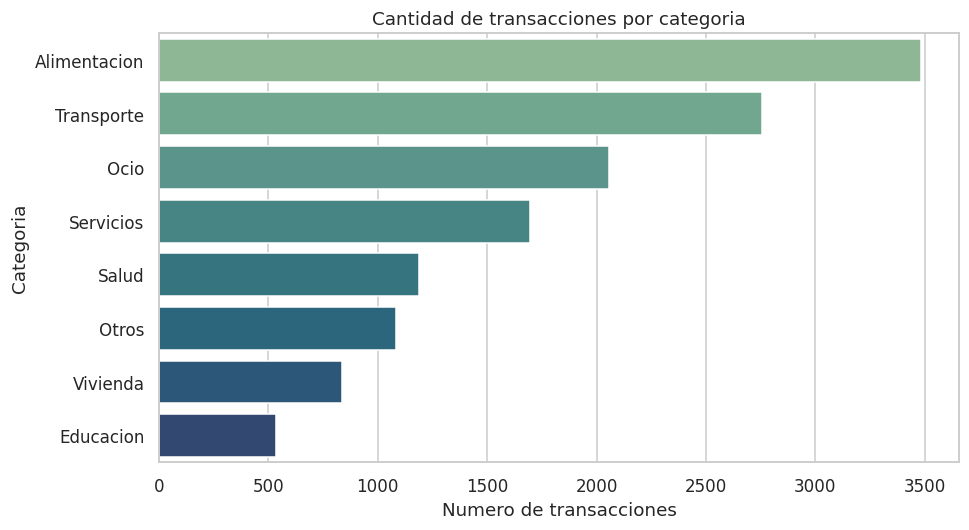

In [8]:
plt.figure(figsize=(9, 5))
sns.barplot(
    x=conteo_categorias.values,
    y=conteo_categorias.index,
    hue=conteo_categorias.index,
    palette="crest",
    legend=False,
)
plt.title("Cantidad de transacciones por categoria")
plt.xlabel("Numero de transacciones")
plt.ylabel("Categoria")
plt.tight_layout()
plt.show()

## 6. Distribucion del perfil financiero

In [9]:
conteo_perfil = df_usr["perfil_financiero"].value_counts()
porcentaje_perfil = (conteo_perfil / len(df_usr) * 100).round(1)

resumen_perfil = pd.DataFrame({
    "usuarios": conteo_perfil,
    "porcentaje (%)": porcentaje_perfil,
})
resumen_perfil

,usuarios,porcentaje (%)
perfil_financiero,,
En observacion,361,45.1
En riesgo,227,28.4
Saludable,212,26.5


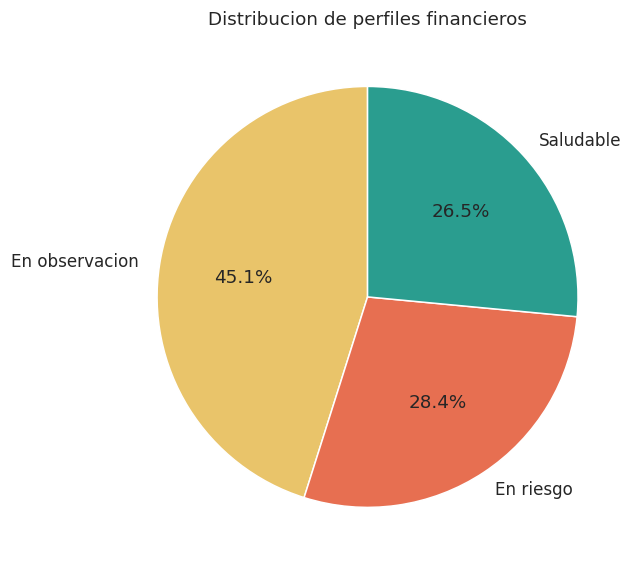

In [10]:
colores_perfil = {"Saludable": "#2a9d8f", "En observacion": "#e9c46a", "En riesgo": "#e76f51"}

plt.figure(figsize=(6, 6))
plt.pie(
    conteo_perfil.values,
    labels=conteo_perfil.index,
    autopct="%1.1f%%",
    colors=[colores_perfil[p] for p in conteo_perfil.index],
    startangle=90,
)
plt.title("Distribucion de perfiles financieros")
plt.tight_layout()
plt.show()

## 7. Estadisticas descriptivas de variables numericas clave

In [11]:
columnas_clave = ["ingreso_mensual", "nivel_endeudamiento", "gasto_total", "ratio_gasto_ingreso", "num_transacciones"]
df_usr[columnas_clave].describe().T

,count,mean,std,min,25%,50%,75%,max
ingreso_mensual,800.0,3868.645100,1588.016116,1000.000,2772.5500,3597.6200,4593.3900,11781.230
nivel_endeudamiento,800.0,36.443000,18.213121,1.300,21.8000,35.2000,49.4000,84.800
gasto_total,800.0,2245.316325,846.190576,553.690,1579.6125,2196.0800,2879.2625,4747.570
ratio_gasto_ingreso,800.0,0.682900,0.414906,0.094,0.3970,0.5925,0.8455,3.587
num_transacciones,800.0,17.041250,5.565138,8.000,12.0000,17.0000,22.0000,26.000


## 8. Distribucion del valor de las transacciones por categoria (outliers)

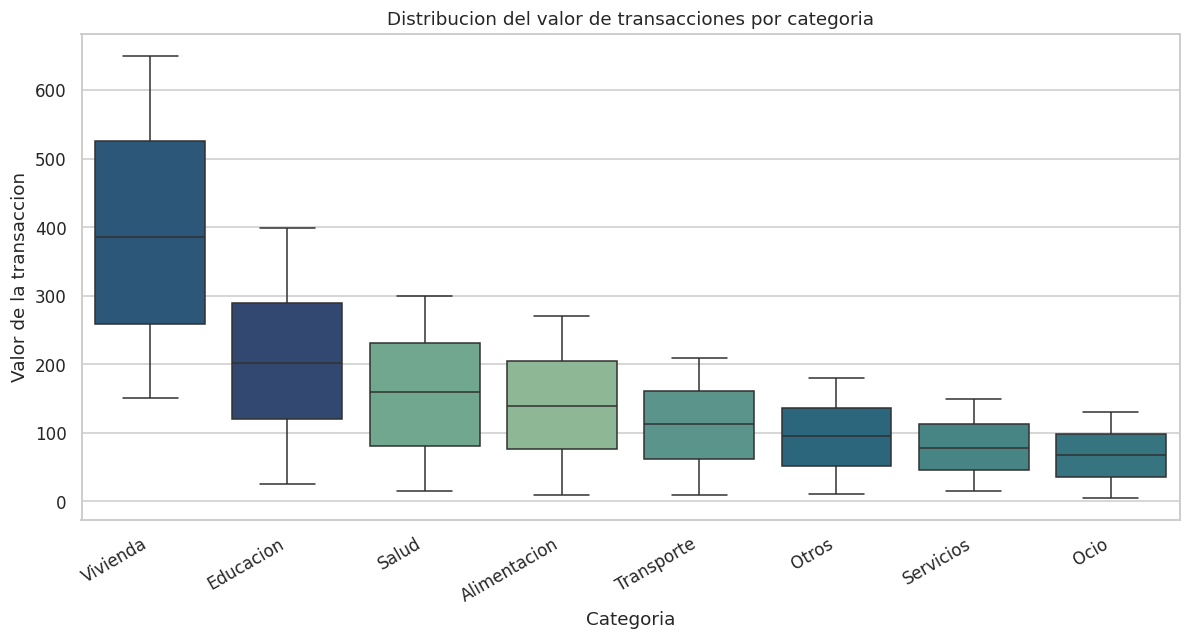

In [12]:
plt.figure(figsize=(11, 6))
orden_categorias = df_trans.groupby("categoria")["valor"].median().sort_values(ascending=False).index
sns.boxplot(
    data=df_trans, x="categoria", y="valor", hue="categoria",
    order=orden_categorias, palette="crest", legend=False,
)
plt.title("Distribucion del valor de transacciones por categoria")
plt.xlabel("Categoria")
plt.ylabel("Valor de la transaccion")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 9. Relacion entre variables financieras y el perfil

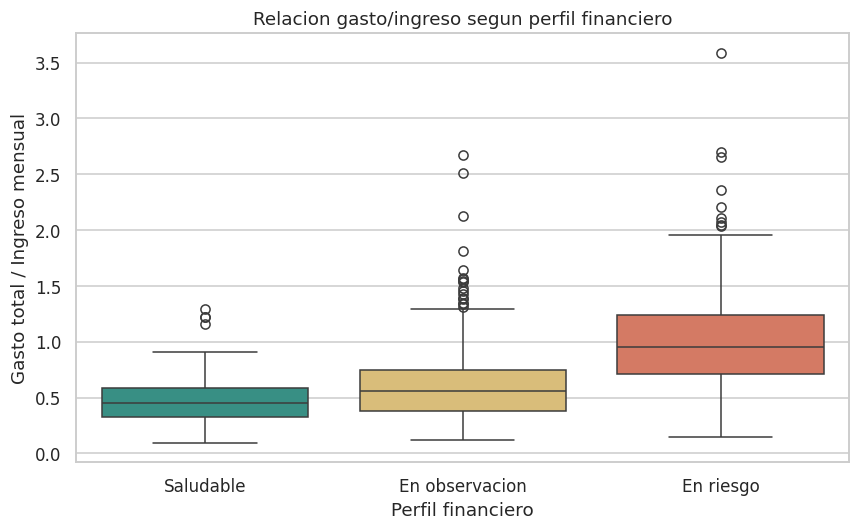

In [13]:
orden_perfil = ["Saludable", "En observacion", "En riesgo"]

plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_usr, x="perfil_financiero", y="ratio_gasto_ingreso", hue="perfil_financiero",
    order=orden_perfil, palette=colores_perfil, legend=False,
)
plt.title("Relacion gasto/ingreso segun perfil financiero")
plt.xlabel("Perfil financiero")
plt.ylabel("Gasto total / Ingreso mensual")
plt.tight_layout()
plt.show()

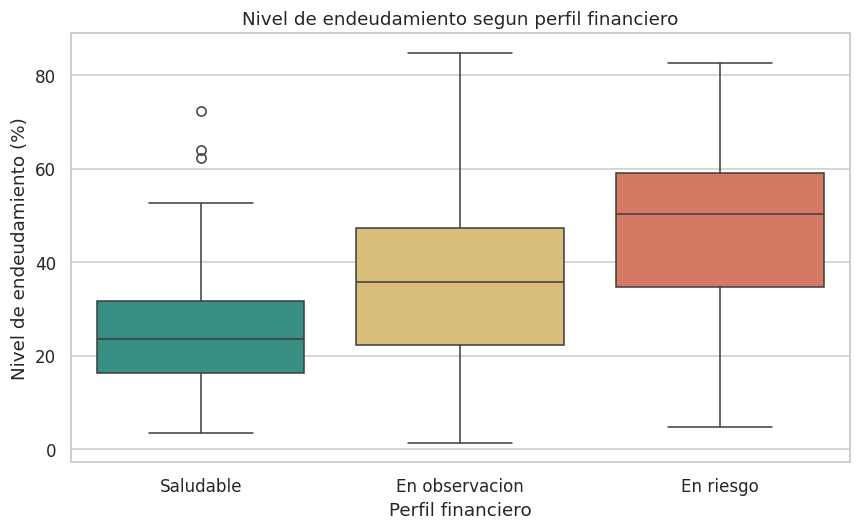

In [14]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_usr, x="perfil_financiero", y="nivel_endeudamiento", hue="perfil_financiero",
    order=orden_perfil, palette=colores_perfil, legend=False,
)
plt.title("Nivel de endeudamiento segun perfil financiero")
plt.xlabel("Perfil financiero")
plt.ylabel("Nivel de endeudamiento (%)")
plt.tight_layout()
plt.show()

In [15]:
tabla_ahorro_perfil = pd.crosstab(df_usr["frecuencia_ahorro"], df_usr["perfil_financiero"], normalize="index").round(3) * 100
tabla_ahorro_perfil = tabla_ahorro_perfil[orden_perfil]
tabla_ahorro_perfil

perfil_financiero,Saludable,En observacion,En riesgo
frecuencia_ahorro,,,
Alta,61.2,34.0,4.8
Baja,2.2,44.6,53.2
Media,26.5,51.6,21.9


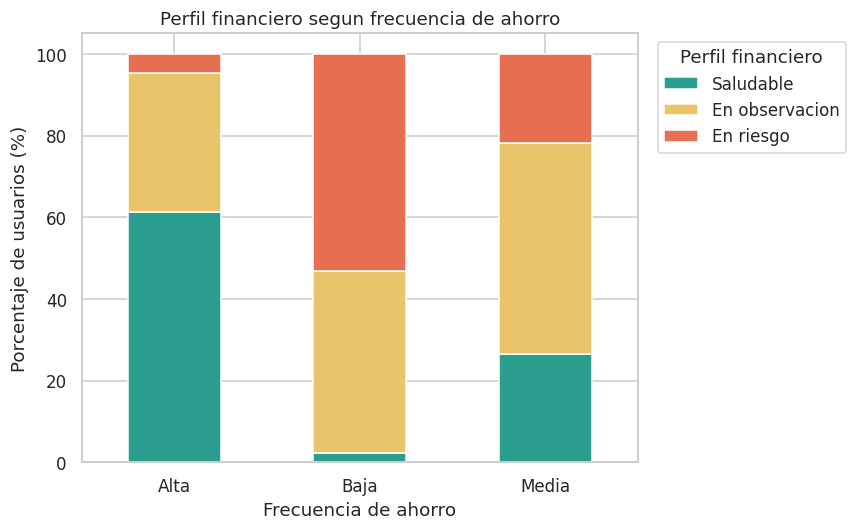

In [16]:
tabla_ahorro_perfil.plot(kind="bar", stacked=True, color=[colores_perfil[p] for p in orden_perfil], figsize=(8, 5))
plt.title("Perfil financiero segun frecuencia de ahorro")
plt.xlabel("Frecuencia de ahorro")
plt.ylabel("Porcentaje de usuarios (%)")
plt.xticks(rotation=0)
plt.legend(title="Perfil financiero", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 10. Correlacion entre variables numericas

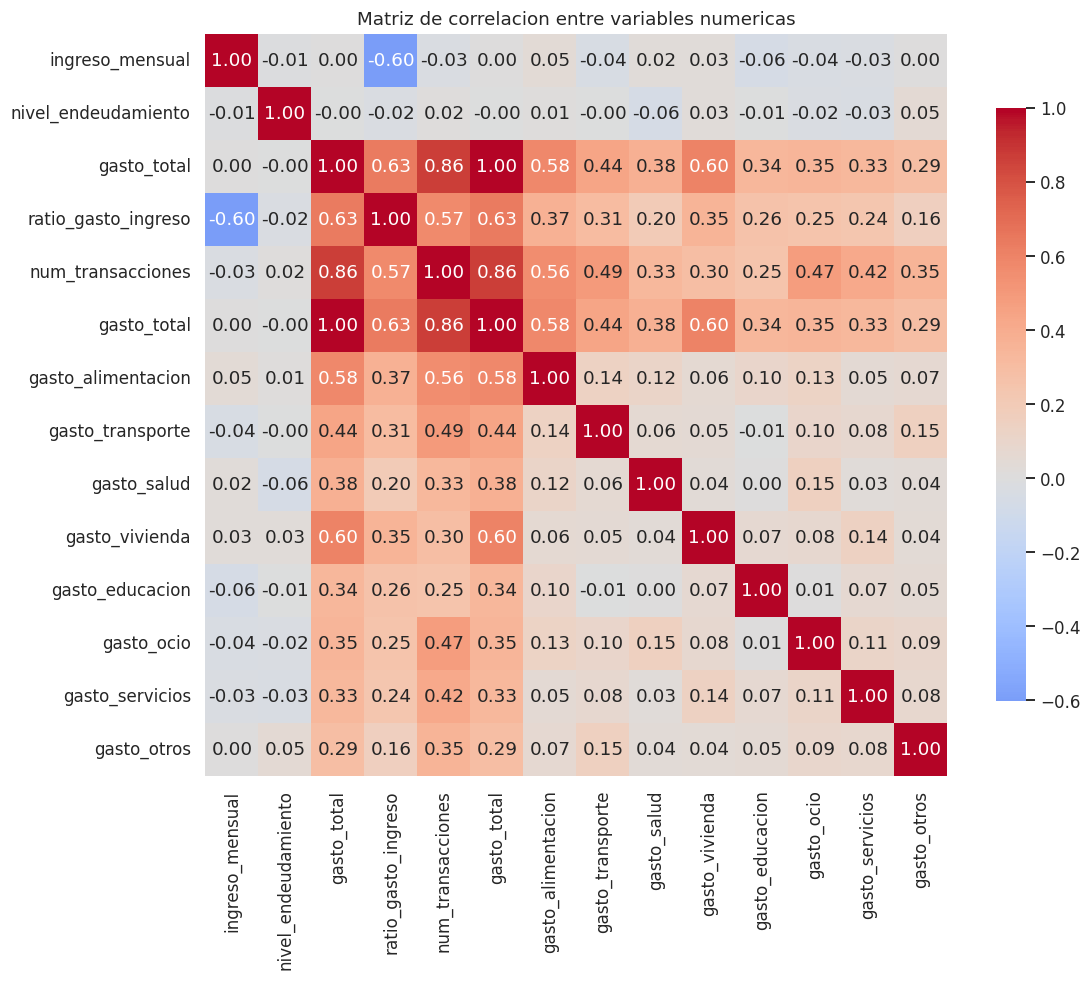

In [17]:
columnas_gasto = [c for c in df_usr.columns if c.startswith("gasto_")]
columnas_correlacion = ["ingreso_mensual", "nivel_endeudamiento", "gasto_total", "ratio_gasto_ingreso", "num_transacciones"] + columnas_gasto

matriz_corr = df_usr[columnas_correlacion].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(matriz_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, cbar_kws={"shrink": 0.8})
plt.title("Matriz de correlacion entre variables numericas")
plt.tight_layout()
plt.show()

## 11. Analisis exploratorio del texto de las descripciones

In [18]:
df_trans["longitud_descripcion"] = df_trans["descripcion"].str.len()
df_trans["cantidad_palabras"] = df_trans["descripcion"].str.split().str.len()

df_trans[["longitud_descripcion", "cantidad_palabras"]].describe().T

,count,mean,std,min,25%,50%,75%,max
longitud_descripcion,13633.0,21.734908,9.503459,3.0,15.0,21.0,28.0,61.0
cantidad_palabras,13633.0,2.978215,1.201663,1.0,2.0,3.0,4.0,8.0


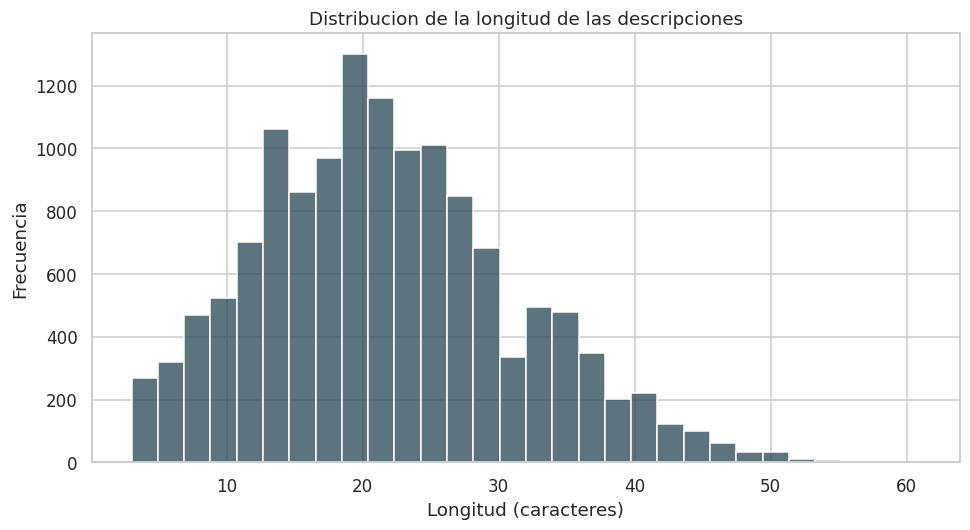

In [19]:
plt.figure(figsize=(9, 5))
sns.histplot(df_trans["longitud_descripcion"], bins=30, color="#264653")
plt.title("Distribucion de la longitud de las descripciones")
plt.xlabel("Longitud (caracteres)")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

In [20]:
import re
from collections import Counter

def tokenizar(texto):
    texto = texto.lower()
    texto = re.sub(r"[^a-zA-Z\s]", " ", texto)
    return texto.split()

print("Palabras mas frecuentes por categoria (top 5), ANTES de limpieza de texto:\n")
for categoria in sorted(df_trans["categoria"].unique()):
    textos = df_trans.loc[df_trans["categoria"] == categoria, "descripcion"]
    tokens = [palabra for texto in textos for palabra in tokenizar(texto)]
    mas_comunes = Counter(tokens).most_common(5)
    print(f"{categoria}: {mas_comunes}")

Palabras mas frecuentes por categoria (top 5), ANTES de limpieza de texto:

Alimentacion: [('ref', 698), ('ara', 298), ('tienda', 296), ('d', 294), ('soriana', 280)]
Educacion: [('online', 163), ('curso', 162), ('matricula', 139), ('ref', 110), ('coursera', 81)]
Ocio: [('ref', 372), ('de', 295), ('bar', 244), ('amigos', 239), ('disney', 236)]
Otros: [('pago', 306), ('transferencia', 274), ('ref', 212), ('oxxo', 142), ('nequi', 139)]
Salud: [('farmacias', 395), ('ref', 257), ('guadalajara', 166), ('eps', 137), ('similares', 135)]
Servicios: [('factura', 535), ('hogar', 386), ('internet', 371), ('plan', 346), ('celular', 343)]
Transporte: [('ref', 566), ('terpel', 303), ('combustible', 299), ('peaje', 277), ('cdmx', 276)]
Vivienda: [('administracion', 175), ('ref', 158), ('pago', 151), ('mexico', 131), ('infonavit', 122)]


## 12. Evolucion temporal del gasto (opcional)

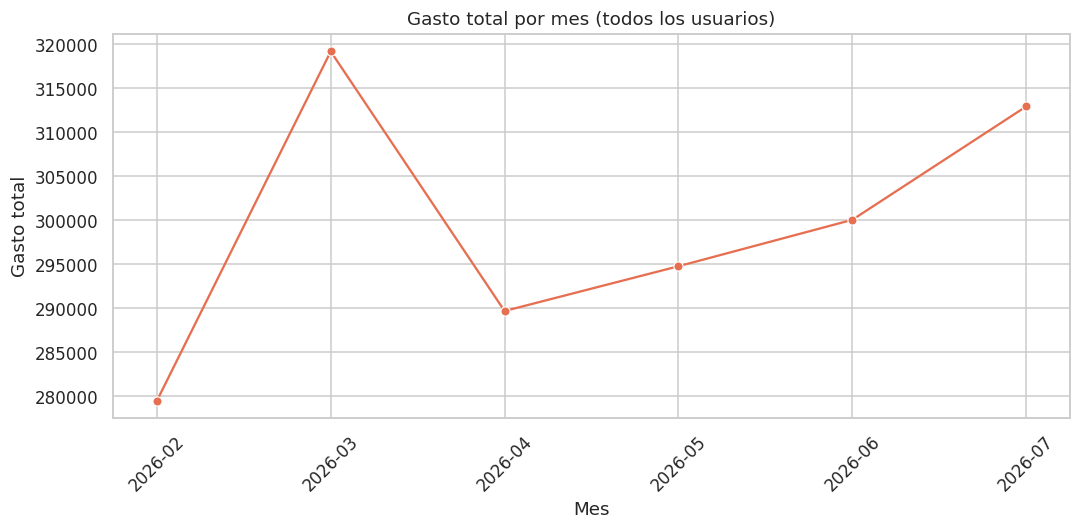

In [21]:
gasto_mensual = (
    df_trans
    .assign(mes=df_trans["fecha"].dt.to_period("M").astype(str))
    .groupby("mes")["valor"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(10, 5))
sns.lineplot(data=gasto_mensual, x="mes", y="valor", marker="o", color="#e76f51")
plt.title("Gasto total por mes (todos los usuarios)")
plt.xlabel("Mes")
plt.ylabel("Gasto total")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Conclusiones del EDA

**Calidad de datos**
- No se encontraron valores nulos, filas duplicadas ni inconsistencias entre `user_id` de ambos datasets.
- No hay transacciones ni ingresos con valores negativos o cero.

**Categorias de gasto**
- Las ocho categorias estan razonablemente representadas; Alimentacion y Transporte concentran la mayor cantidad de transacciones (son las mas frecuentes en la vida real), mientras que Vivienda y Educacion aparecen con menor frecuencia pero valores individuales mas altos — esto se confirma en los boxplots de la seccion 8.

**Perfil financiero**
- La distribucion de clases quedo razonablemente balanceada (ni una clase domina de forma aplastante), lo cual es favorable para entrenar el clasificador sin necesitar tecnicas agresivas de balanceo.
- `ratio_gasto_ingreso` y `nivel_endeudamiento` muestran una relacion clara y creciente con el perfil de riesgo (seccion 9), confirmando que son variables predictivas fuertes para el modelo de perfil.
- `frecuencia_ahorro` tambien se relaciona con el perfil: los usuarios con ahorro "Alta" concentran una proporcion mayor de perfil "Saludable".

**Texto de las descripciones**
- Las descripciones contienen ruido tipico de datos bancarios reales: mayusculas, codigos de referencia, numeros de comercio y nombres de ciudad. Esto confirma que el paso de **limpieza de texto** (normalizar mayusculas/tildes, remover codigos y numeros, remover ciudades) es necesario antes de vectorizar con TF-IDF para el clasificador de gastos.
- Ademas, **1,400 transacciones (10.27%) usan una descripcion generica** ("PAGO", "COMPRA", "TRANSFERENCIA", "RETIRO", "CONSUMO", etc.) que no revela la categoria por si sola — y estas se reparten entre las 8 categorias reales, no en una sola. Esto es intencional: sin esta ambiguedad, el vocabulario de cada categoria queda cerrado y perfectamente separable, y el clasificador de gastos entrenado en el Paso 5 daba un accuracy irrealista de 100%. Con esta ambiguedad, el modelo final alcanza ~90% de accuracy, un resultado mucho mas representativo de un problema real de clasificacion de texto.
- Tambien se introdujeron errores tipograficos simulados en una fraccion de las descripciones con nombre de comercio (por ejemplo, "SPOTIY" en vez de "SPOTIFY"), reforzando la necesidad de un pipeline de limpieza robusto.

**Proximos pasos (siguiente notebook/seccion)**
1. Limpieza de texto de `descripcion` (normalizacion, remocion de ruido).
2. Ingenieria de atributos: vectorizacion TF-IDF para el modelo de gastos; construccion de features agregadas ya disponibles (`ratio_gasto_ingreso`, gasto por categoria) para el modelo de perfil.
3. Entrenamiento y evaluacion de ambos modelos (clasificador de gastos y clasificador de perfil financiero).